In [48]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys
ROOT = Path.cwd().parent.parent
sys.path.append(str(ROOT))
from src.loading_data.load_data import get_data
from src.stream_3.gower_distance import get_gower
from sklearn.preprocessing import StandardScaler
import umap 
import matplotlib.pyplot as plt
import hdbscan
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm


In [49]:
df = get_data()
categorical_cols = ['Gend3', 'Disab3',  'Eth7'] # VolAny is catgeorical but doesnt need to be encoded
continuous_cols = ['NSSEC5', 'Educ6', 'IMD10', 'nchild', 'Motiva_POP', 'motivb_POP','motivc_POP', 'motivd_POP','Age9', 'WorkStat10']
drop_cols = ['year', 'active', 'MEMS7_ALL']
df_2016 = df[df['year'] == '2016/17']
active, mems = df_2016['active'].values, df_2016['MEMS7_ALL'].values
cat_bool_mask = [True if c in categorical_cols else False for c in df_2016.columns]

DataFrame Cleaned Sucessfully...
DataFrame Information:
>>> Columns:
Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'MEMS7_ALL',
       'year', 'IMD10', 'nchild', 'VolAny', 'Motiva_POP', 'motivb_POP',
       'motivc_POP', 'motivd_POP', 'WorkStat10', 'active'],
      dtype='str')
>>> Shape (86089, 17)
--------------------------
Columns NOT in Master.csv:
>>> ['nadults', 'motivex2a', 'motivex2b', 'motivex2c', 'motivex2d', 'inclus_a', 'inclus_b', 'inclus_c', 'comm2', 'limfreti1', 'limfreti2', 'limfreti3', 'limfreti4', 'limfreti5', 'limfreti6', 'limfreti7', 'limfreti8']
Unhealthy Columns:
>>> ['motive_POP', 'comm1', 'anxious', 'happy', 'lifesat', 'lone', 'worthw', 'indev', 'indevtry']


In [50]:
df_2016_clean = df_2016.drop(columns=(drop_cols))
print(df_2016_clean.columns)
gower_matrix = get_gower(categorical_cols, df_2016_clean)


Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'IMD10', 'nchild',
       'VolAny', 'Motiva_POP', 'motivb_POP', 'motivc_POP', 'motivd_POP',
       'WorkStat10'],
      dtype='str')
0 | True | Gend3
1 | True | Disab3
2 | False | Age9
3 | True | Eth7
4 | False | NSSEC5
5 | False | Educ6
6 | False | IMD10
7 | False | nchild
8 | False | VolAny
9 | False | Motiva_POP
10 | False | motivb_POP
11 | False | motivc_POP
12 | False | motivd_POP
13 | False | WorkStat10


In [51]:
emb = umap.UMAP(metric = 'precomputed', random_state = 42).fit_transform(gower_matrix)

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


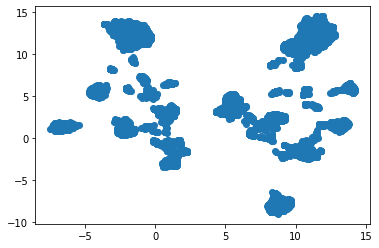

In [52]:
plt.scatter(emb[:,0], emb[:,1])

In [54]:
cluster = hdbscan.HDBSCAN(min_cluster_size = 250, min_samples = 40)
labels = cluster.fit_predict(emb)
print(len((set(labels))))

17


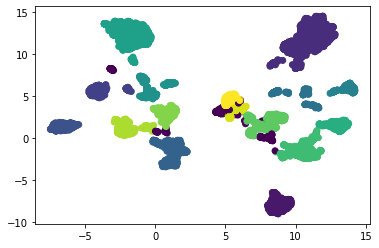

In [55]:
plt.scatter(emb[:,0], emb[:,1], c=labels)

In [56]:
type(emb)

numpy.ndarray

In [30]:
hdb = hdbscan.HDBSCAN(gen_min_span_tree=True).fit(emb)
hdb.relative_validity_
unclustered = len([c for c in hdb.labels_ if c == -1])/len(hdb.labels_)
unclustered

0.046875

In [ ]:
def hdb_dbcv(
        emb : np.ndarray,
        min_samples: list[int] = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
        min_cluster_size : list[int] = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500],
        cluster_selection_method : list[str]  = ['eom', 'leaf'],
        metric : list[str] = ['euclidean', 'manhattan']) -> pd.DataFrame:
    outputs = []
    for min_sample in tqdm(min_samples):
        for min_cluster in min_cluster_size:
            for cluster_selection in cluster_selection_method:
                for m in metric:
                    hdb = hdbscan.HDBSCAN(
                        min_samples = min_sample,
                        min_cluster_size = min_cluster,
                        cluster_selection_method = cluster_selection,
                        metric = m,
                        gen_min_span_tree = True
                    ).fit(emb)
                    num_clusters = len(set(hdb.labels_))
                    unclustered_prop = len([c for c in hdb.labels_ if c == -1])/len(hdb.labels_)
                    dbcv = hdb.relative_validity_
                    outputs.append([min_sample, min_cluster, cluster_selection, m, num_clusters, unclustered_prop, dbcv])
    df_output = pd.DataFrame(outputs, columns = ['min_sample', 'min_cluster', 'cluster_selection', 'm', 'num_clusters', 'unclustered_prop', 'dbcv'])
    print(df_output.sort_values('dbcv', ascending=False).head())
    return df_output

In [ ]:
min_samples = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
min_cluster_size = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
cluster_selection_method = ['eom', 'leaf']
metric = ['euclidean', 'manhattan']
outputs = []
for min_sample in tqdm(min_samples):
    for min_cluster in min_cluster_size:
        for cluster_selection in cluster_selection_method:
            for m in metric:
                hdb = hdbscan.HDBSCAN(
                    min_samples = min_sample,
                    min_cluster_size = min_cluster,
                    cluster_selection_method = cluster_selection,
                    metric = m,
                    gen_min_span_tree = True
                ).fit(emb)
                num_clusters = len(set(hdb.labels_))
                unclustered_prop = len([c for c in hdb.labels_ if c == -1])/len(hdb.labels_)
                dbcv = hdb.relative_validity_
                outputs.append([min_sample, min_cluster, cluster_selection, m, num_clusters, unclustered_prop, dbcv])
df_output = pd.DataFrame(outputs, columns = ['min_sample', 'min_cluster', 'cluster_selection', 'm', 'num_clusters', 'unclustered_prop', 'dbcv'])
print(df_output.sort_values('dbcv', ascending=False).head())

                

100%|██████████| 11/11 [01:25<00:00,  7.77s/it]


In [47]:
df_output.sort_values('dbcv', ascending=False).head()

,min_sample,min_cluster,cluster_selection,m,num_clusters,unclustered_prop,dbcv
176,40,250,eom,euclidean,17,0.028043,0.519238
17,5,250,eom,manhattan,16,0.038551,0.516847
13,5,200,eom,manhattan,16,0.038551,0.516847
24,5,350,eom,euclidean,15,0.035685,0.508286
12,5,200,eom,euclidean,15,0.035685,0.508286


In [37]:
output = []
x = [10,12,13]
output.append(x)
output
y = [19,20,1]
output.append(y)
output

[[10, 12, 13], [19, 20, 1]]

In [33]:
y = pd.Series(['yes', 'no', 'maybe'], axis=1)
y

TypeError: Series.__init__() got an unexpected keyword argument 'axis'

In [27]:
len(set(hdb.labels_))

134